# External anchoring of the surface-to-capacity coefficient

Detections are **surfaces**; registries hold **capacities**. The chain applies a single coefficient
of **5.5 m2/kWp** to the planimetric area, derived from a reference database's median ratio of
6.3 m2/kWp corrected for tilt.

That coefficient has two known weaknesses, both structural:

1. it is a **single national average**, while local fleets differ in vintage and therefore in
   module efficiency;
2. it is calibrated on a **relatively old** database, whose lower efficiency inflates the surface
   required per kWp.

This notebook builds an **external anchor**. On the units where the registry and the corrected
estimate already agree, the size distribution on the detection side should coincide with the
registry's. A systematic offset measures a bias in the coefficient directly.

**Non-circularity, and it is the point of the design.** The anchor is computed *only* on units with
status `within`, those whose registry value already falls inside the credible interval. Those are
by construction the units whose status the audit is not trying to establish, so the coefficient is
not calibrated on the very discrepancy it is later used to measure. Anchoring on the flagged units
would be circular in a way that is easy to miss and fatal to the argument.

**A caveat of convention.** The two sides do not count the same object. On the registry side an
extension or a change of contract splits a system into several records; on the detection side
clustering merges them into a single array. The comparison reads as an order-of-magnitude anchor,
not as a fine calibration.

## 0. Config

In [1]:
import sys
from pathlib import Path

import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _find_root(start, marker='paths.py'):
    for parent in [start, *start.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(marker)


ROOT = _find_root(Path.cwd())
sys.path.insert(0, str(ROOT))
import paths
import style
import units
style.apply()

FIGS_DIR = paths.FIGURES
FIG_PREFIX = 'eval_conversion'

# The coefficient the chain retains, and the bounds of specification C
BASELINE_COEF = 5.5
SPEC_LOW, SPEC_HIGH = 5.0, 6.0

# The most common single- and three-phase connection tiers
KVA_TIERS = (3, 6, 9)

COMPARISON_FILE = paths.AUDIT_RTE
RTE_FILE = ROOT / '0_data' / 'src' / 'rte' / 'installations_rte.csv'
DETECTIONS_FILE = (ROOT / '0_data' / 'postprocess' / 'filtering'
                   / paths.DETECTIONS)

if not RTE_FILE.exists():
    raise FileNotFoundError(
        "This notebook needs the operator's per-installation registry extract, which is "
        "not redistributable and is therefore not part of the release. Its outputs ship in "
        "data/intermediate, and the conclusions that depend on the conversion coefficient "
        "are reproducible through specification C of the robustness battery. See the "
        "banner above and the repository README, category 4."
    )


## 1. Loading, and restriction to the non-circular subset

Both sources are mapped to **reporting units** before the selection, Paris and its inner ring being
merged. Without that step the four inner-ring departments attach to no status at all and drop out
silently.

> **This section does not run from the released data.**
>
> It needs the transmission system operator's per-installation extract, which is
> not redistributable. The aggregates released in its place (see
> `data/source/rte_derived/README.md`) carry every quantity the audit itself
> consumes, but not the full capacity distribution this section pools over.
>
> The section is kept, and its outputs ship in `data/intermediate`, so the
> result is inspectable even where the computation cannot be replayed. What is
> shipped instead is `rte_capacity_deciles.csv`, deciles for three illustrative
> units, which demonstrates the shape of the distribution without standing in
> for it.


In [2]:
comparison = pd.read_csv(COMPARISON_FILE, dtype={'dpt': str})
within = set(comparison.loc[comparison['status_kwp'] == 'within', 'dpt'])

rte = pd.read_csv(RTE_FILE, dtype={'code_departement': str}, low_memory=False)
rte['unit'] = units.to_unit(rte['code_departement'])

det = gpd.read_file(DETECTIONS_FILE, columns=['dpt', 'kWp'], ignore_geometry=True)
det['unit'] = units.to_unit(det['dpt'].astype(str))

# The kWp column is ALREADY converted at the baseline coefficient, so moving to
# another coefficient c is a multiplication by BASELINE_COEF / c.
rte_w = rte.loc[rte['unit'].isin(within), 'p_inst'].dropna()
det_w = det.loc[det['unit'].isin(within), 'kWp'].dropna()

print(f"within units: {len(within)} / {len(comparison)}")
print(f"registry   : {len(rte_w):,} connections")
print(f"detections : {len(det_w):,} arrays")

unites within : 60 / 93
RTE  : 748,069 raccordements
DPVM : 410,700 arrays detectes


## 2. The coefficient the registry implies

`implied coefficient = baseline x central tendency(detections) / central tendency(registry)`.

Two central tendencies are reported. The **median** is the reference estimator, robust to the tails
and to the convention caveat above. The **mean** is a control: it is sensitive to large systems, and
therefore to how a system is split into records, but it should not diverge wildly from the median.
If it did, the convention caveat would be doing more work than assumed.

In [3]:
med_rte, med_det = rte_w.median(), det_w.median()
mean_rte, mean_det = rte_w.mean(), det_w.mean()

implied_median = BASELINE_COEF * med_det / med_rte
implied_mean = BASELINE_COEF * mean_det / mean_rte

print(f"medians : detections {med_det:.2f} kWp | registry {med_rte:.2f} kWp"
      f"  ->  {implied_median:.2f} m2/kWp  ({100 * (implied_median / BASELINE_COEF - 1):+.1f}%)")
print(f"means   : detections {mean_det:.2f} kWp | registry {mean_rte:.2f} kWp"
      f"  ->  {implied_mean:.2f} m2/kWp  ({100 * (implied_mean / BASELINE_COEF - 1):+.1f}%)")
print()
for name, val in (('median', implied_median), ('mean', implied_mean)):
    inside = SPEC_LOW <= val <= SPEC_HIGH
    print(f"{name:>8} : {'INSIDE' if inside else 'OUTSIDE'} the specification C range "
          f"[{SPEC_LOW}, {SPEC_HIGH}]")

medianes : DPVM 3.07 kWc | RTE 3.00 kWc  ->  5.63 m2/kWc  (+2.3%)
moyennes : DPVM 4.89 kWc | RTE 4.71 kWc  ->  5.71 m2/kWc  (+3.8%)

 mediane : DANS la plage spec C [5.0, 6.0]
 moyenne : DANS la plage spec C [5.0, 6.0]


## 3. Why a quantile-by-quantile comparison settles nothing

The registry is **not a continuous distribution**. Connection capacities pile up on the contractual
tiers, and that discretisation runs through the whole body of the distribution, not only the upper
tail.

The consequence is direct: a quantile-by-quantile comparison mostly measures the registry's
staircase, not a disagreement about the coefficient. That is precisely why the anchor in section 2
is read off the central tendency instead. This section exists to make the negative result explicit,
because the Q-Q plot is the first thing a reader will want to interpret, and interpreting it as a
coefficient disagreement would be wrong.

In [4]:
qs = np.arange(0.01, 1.00, 0.01)
q_rte = rte_w.quantile(qs).to_numpy()
q_det = det_w.quantile(qs).to_numpy()

print("probability mass on the tiers, registry side:")
for t in KVA_TIERS:
    print(f"  exactly {t}.0 kWp : {(rte_w == t).mean():6.1%}  "
          f"(detections within +/-0.05 kWp : {((det_w - t).abs() < 0.05).mean():5.2%})")

report_q = [0.10, 0.25, 0.50, 0.75, 0.90]
qtab = pd.DataFrame({
    'registry': rte_w.quantile(report_q),
    'detections': det_w.quantile(report_q),
})
qtab['ratio'] = qtab['detections'] / qtab['registry']
qtab['implied_coef'] = BASELINE_COEF * qtab['ratio']
print()
print(qtab.round(2))

masses de probabilite sur les paliers, cote RTE :
  exactement 3.0 kWc :  26.6%  (DPVM a +/-0.05 kWc : 10.33%)
  exactement 6.0 kWc :  13.3%  (DPVM a +/-0.05 kWc : 0.40%)
  exactement 9.0 kWc :   3.9%  (DPVM a +/-0.05 kWc : 0.11%)

       RTE  DPVM  ratio  coef implicite
0.10  2.20  2.20   1.00            5.50
0.25  2.90  2.76   0.95            5.23
0.50  3.00  3.07   1.02            5.63
0.75  6.00  4.20   0.70            3.85
0.90  7.88  8.59   1.09            6.00


## 4. Figure

**(a)** the two empirical cumulative distributions. The registry's jumps at the 3, 6 and 9 kVA tiers
are visible to the eye, and that discretisation is what makes the quantile comparison unusable.

**(b)** the corresponding Q-Q plot. The shaded band is the envelope of specification C, that is,
what the detected quantiles would become if converted at the 5.0 and 6.0 m2/kWp bounds. The vertical
segments are the tiers: along a tier the registry quantile does not move while the detected quantile
keeps rising, which is the staircase seen sideways.

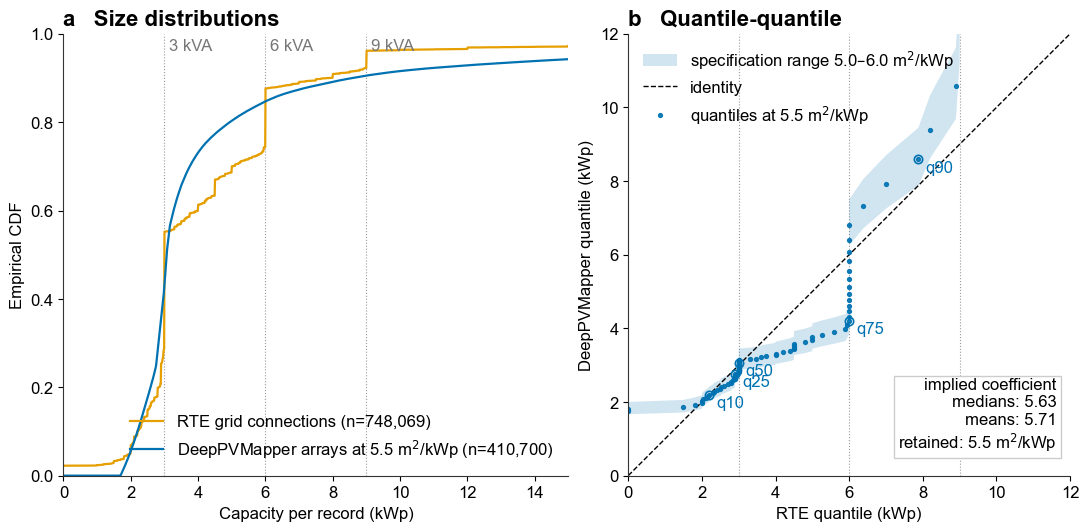

In [6]:
C_RTE, C_DET = style.OKABE_ITO['orange'], style.OKABE_ITO['blue']

# Font sizes
FONT_TITLE = 16
FONT_OTHER = 12

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(11, 5.2),
    layout='constrained'
)

# ---- (a) fonctions de repartition empiriques -------------------------
grid = np.linspace(0, 15, 1500)

for s, c, lab in (
    (rte_w, C_RTE, f"RTE grid connections (n={len(rte_w):,})"),
    (det_w, C_DET,
     f"DeepPVMapper arrays at {BASELINE_COEF} m$^2$/kWp "
     f"(n={len(det_w):,})")
):
    ecdf = (
        np.searchsorted(np.sort(s.to_numpy()), grid, side='right')
        / len(s)
    )
    ax1.plot(
        grid, ecdf,
        color=c,
        lw=1.6,
        label=lab
    )

for t in KVA_TIERS:
    ax1.axvline(
        t,
        color='#999999',
        ls=':',
        lw=0.8,
        zorder=0
    )
    ax1.annotate(
        f"{t} kVA",
        (t, 0.99),
        xytext=(3, 0),
        textcoords='offset points',
        fontsize=FONT_OTHER,
        color='#777777',
        va='top'
    )

ax1.set_xlim(0, 15)
ax1.set_ylim(0, 1)

ax1.set_xlabel(
    'Capacity per record (kWp)',
    fontsize=FONT_OTHER
)
ax1.set_ylabel(
    'Empirical CDF',
    fontsize=FONT_OTHER
)

ax1.tick_params(
    axis='both',
    labelsize=FONT_OTHER
)

ax1.set_title(
    'a   Size distributions',
    fontweight='bold',
    fontsize=FONT_TITLE,
    loc='left'
)

ax1.legend(
    loc='lower right',
    fontsize=FONT_OTHER,
    frameon=False
)


# ---- (b) quantile-quantile --------------------------------------------
hi = 12

ax2.fill_between(
    q_rte,
    q_det * BASELINE_COEF / SPEC_HIGH,
    q_det * BASELINE_COEF / SPEC_LOW,
    color=C_DET,
    alpha=0.18,
    lw=0,
    label=f"specification range {SPEC_LOW}–{SPEC_HIGH} m$^2$/kWp"
)

ax2.plot(
    [0, hi],
    [0, hi],
    color='black',
    ls='--',
    lw=1.0,
    label='identity'
)

ax2.plot(
    q_rte,
    q_det,
    'o',
    ms=2.8,
    color=C_DET,
    alpha=0.9,
    label=f"quantiles at {BASELINE_COEF} m$^2$/kWp"
)

for t in KVA_TIERS:
    ax2.axvline(
        t,
        color='#999999',
        ls=':',
        lw=0.8,
        zorder=0
    )

marked = np.isin(
    np.round(qs, 2),
    np.array(report_q)
)

ax2.plot(
    q_rte[marked],
    q_det[marked],
    'o',
    ms=6,
    mfc='none',
    mec=C_DET,
    mew=1.2
)

for q, x, y in zip(
    qs[marked],
    q_rte[marked],
    q_det[marked]
):
    ax2.annotate(
        f"q{int(round(q * 100))}",
        (x, y),
        xytext=(5, -9),
        textcoords='offset points',
        fontsize=FONT_OTHER,
        color=C_DET
    )

ax2.set_xlim(0, hi)
ax2.set_ylim(0, hi)
ax2.set_aspect('equal')

ax2.set_xlabel(
    'RTE quantile (kWp)',
    fontsize=FONT_OTHER
)
ax2.set_ylabel(
    'DeepPVMapper quantile (kWp)',
    fontsize=FONT_OTHER
)

ax2.tick_params(
    axis='both',
    labelsize=FONT_OTHER
)

ax2.set_title(
    'b   Quantile-quantile',
    fontweight='bold',
    fontsize=FONT_TITLE,
    loc='left'
)

ax2.legend(
    loc='upper left',
    fontsize=FONT_OTHER,
    frameon=False
)

ax2.text(
    0.97,
    0.05,
    f"implied coefficient\n"
    f"medians: {implied_median:.2f}\n"
    f"means: {implied_mean:.2f}\n"
    f"retained: {BASELINE_COEF:.1f} m$^2$/kWp",
    transform=ax2.transAxes,
    ha='right',
    va='bottom',
    fontsize=FONT_OTHER,
    bbox=dict(
        facecolor='white',
        edgecolor='#cccccc',
        pad=3
    )
)

# ---------------------------------------------------------------------
# Export
# ---------------------------------------------------------------------
FIGS_DIR.mkdir(parents=True, exist_ok=True)

fig.savefig(
    FIGS_DIR / f'{FIG_PREFIX}_size_distributions.png',
    dpi=style.EXPORT_DPI,
    bbox_inches='tight'
)

fig.savefig(
    FIGS_DIR / f'{FIG_PREFIX}_size_distributions.pdf',
    bbox_inches='tight'
)

plt.show()

## 5. What this establishes, and what it does not

**Established.** On the well-calibrated units the registry implies a coefficient of
**5.63 m2/kWp** by medians and **5.71 m2/kWp** by means, against **5.5** retained. Both fall inside
the [5.0, 6.0] range of specification C, and the closer of the two is 2.3% away. The chain's
coefficient is therefore not contradicted by the registry, and the sensitivity range brackets it
correctly.

Both estimators sit *above* 5.5, which means the chain is slightly **generous** in capacity per
square metre, and its corrected estimate correspondingly high. That direction is the one
unfavourable to the paper's under-reporting conclusion: the coefficient's residual bias does not
manufacture the result, it works against it. A bias in the other direction would have needed
addressing rather than reporting.

**Not established.** Any quantile-by-quantile agreement. The registry puts more than a quarter of
its records on exactly 3.0 kWp and 13% on 6.0 kWp, and that staircase dominates every quantile
comparison. A claim of the form "the distributions agree to within x% over the interquartile range"
is not available here and should not be made: at the third quartile the ratio is 0.70, entirely
attributable to the 6 kVA tier and not to any disagreement about the coefficient.